# Autoencoder MNIST

## Importing required packages

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import torch 
import torch.nn as nn 
import torch.nn.functional as F
from  torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim
from torchvision import datasets,transforms

## Defining transforms

In [2]:
transforms=transforms.ToTensor()

## Downloading requried data

In [3]:
from torchvision import datasets, transforms

data_root = r'C:\Users\Divyansh Sharma\Downloads\archive (2)\mnist_png'  

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(root=data_root + r'\training', transform=transform)
test_data  = datasets.ImageFolder(root=data_root + r'\testing', transform=transform)

In [4]:
print(len(train_data), len(test_data))

60000 10000


## Defining dataloaders

In [5]:
valid_size=0.2

# IMPORTANT 
batch_size=20

num_workers=0

train_length = len(train_data)

# obtain training dataset indices that will be used for validation dataset
indices = list(range(train_length))

np.random.shuffle(indices)
split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders for train, test and validation dataset
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, 
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, 
    num_workers=num_workers)

In [6]:

# Printing the length of our train, valid and test dataloaders
# NOTE : Here batch size is 20
len(train_loader),len(valid_loader),len(test_loader)

(2400, 600, 500)

In [7]:
# checking our data
dataiter=iter(train_loader)
images,labels=next(dataiter)
print(images, images.shape, len(images), images[0].shape)
print()
print(labels,labels.shape,len(labels))

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0.

## Visualizing a Training batch

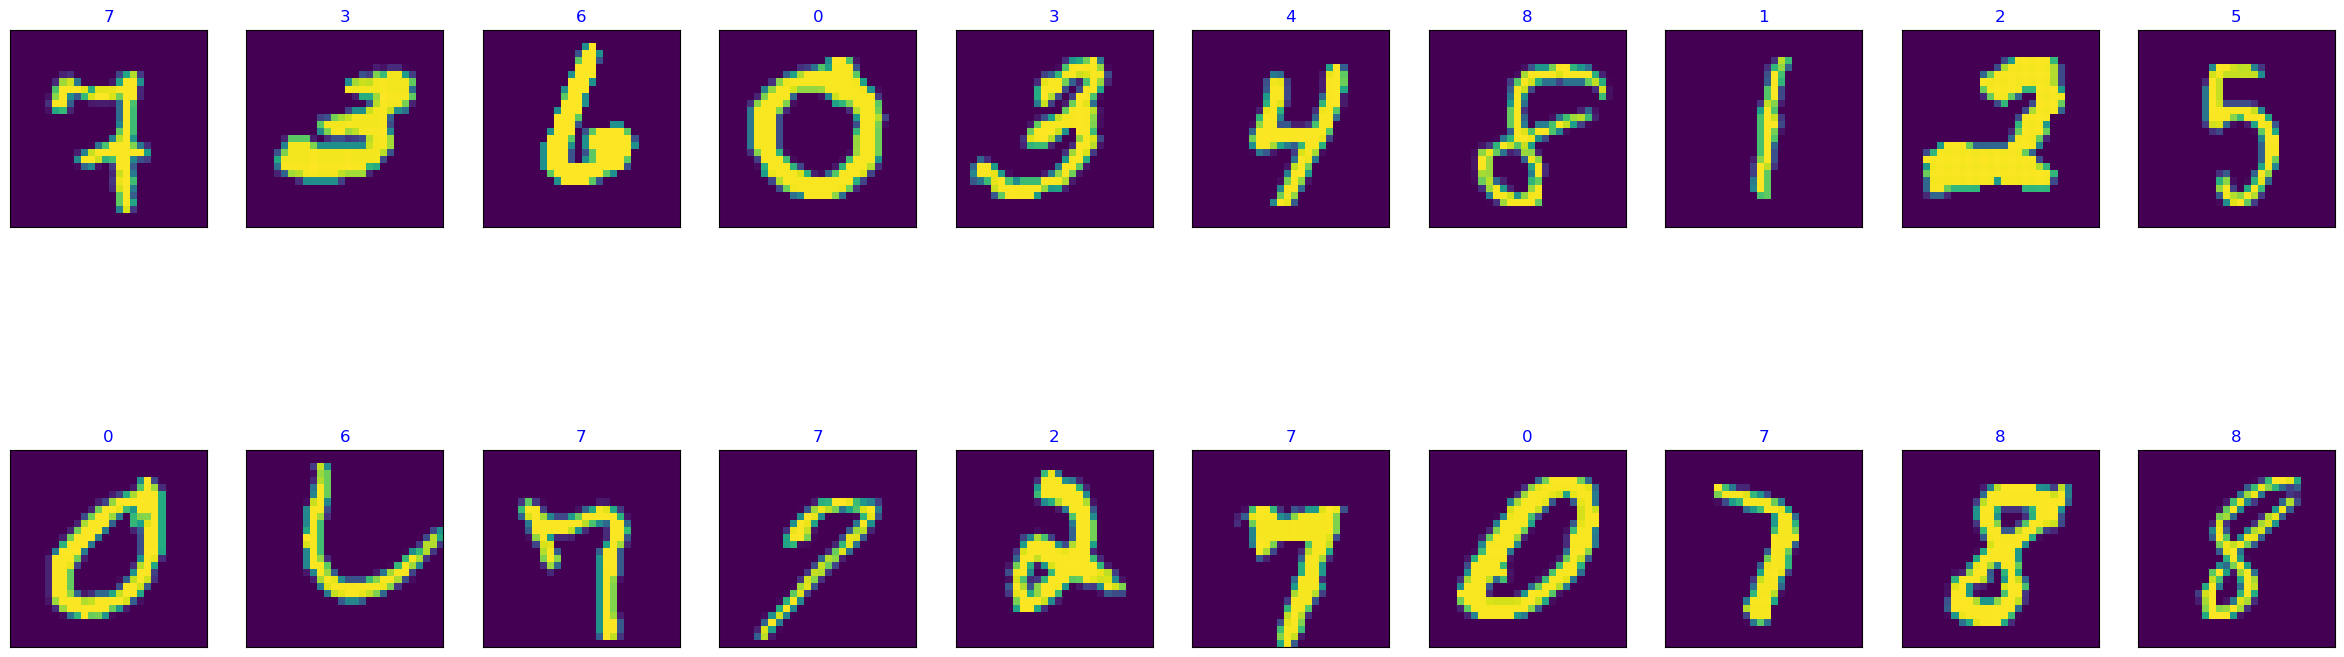

In [8]:
# Displaying images and labels of a batch
fig=plt.figure(figsize=(30,10))
for i in range(len(labels)):
    ax=fig.add_subplot(2,10,i+1,xticks=[],yticks=[])
    plt.imshow(np.squeeze(images[i]))
    ax.set_title(labels[i].item(),color='blue')

## Defining Architecture

In [9]:
class F_Auto_MNIST(nn.Module):
    def __init__(self,en_dim):
        super(F_Auto_MNIST,self).__init__()
        self.encoder=nn.Linear(784,en_dim)
        self.decoder=nn.Linear(en_dim,784)
    
    def forward(self,x):
        x=F.relu(self.encoder(x))
        x=F.sigmoid(self.decoder(x))
        return x

class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(Tran_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.ConvTranspose2d(4,16,2,stride=2)
        self.de_conv2=nn.ConvTranspose2d(16,1,2,stride=2)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x=F.relu(self.de_conv1(x))
        x=F.sigmoid(self.de_conv2(x))
        return x

class upsamp_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(upsamp_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.Conv2d(4,16,3,padding=1)
        self.de_conv2=nn.Conv2d(16,1,3,padding=1)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x = F.upsample(x, scale_factor=2, mode='nearest')
        x=F.relu(self.de_conv1(x))
        x = F.upsample(x, scale_factor=2, mode='nearest')
        x=F.sigmoid(self.de_conv2(x))
        return x

#Since the images are normalized between 0 and 1, we need to use a sigmoid activation on the output layer to get values that match this input value range.

In [10]:
model_1=F_Auto_MNIST(32)
model_2=Tran_conv_Auto_MNIST()
model_3=upsamp_conv_Auto_MNIST()

def weight_init_normal(m):
    classname=m.__class__.__name__
    if classname.find('Linear')!=-1:
        n = m.in_features
        y = (1.0/np.sqrt(n))
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)

model_1.apply(weight_init_normal)

use_cuda=True
if use_cuda and torch.cuda.is_available():
  model_1.cuda()
  model_2.cuda()
  model_3.cuda()
print(model_1,'\n\n\n\n',model_2,'\n\n\n\n',model_3,'\n\n\n\n','On GPU : ',torch.cuda.is_available())

F_Auto_MNIST(
  (encoder): Linear(in_features=784, out_features=32, bias=True)
  (decoder): Linear(in_features=32, out_features=784, bias=True)
) 



 Tran_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
  (de_conv2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
) 



 upsamp_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (de_conv2): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
) 



 O

## Defining our Loss Function

In [11]:
# Used when comapring pixel values.
criterion=nn.MSELoss()

## Denoising Autoencoder Approach

This project trains each autoencoder as a denoising autoencoder rather than a plain reconstruction autoencoder. The key difference:

- **Input to the model:** a noisy version of the digit image, created by adding random Gaussian noise and clipping pixel values back to the valid [0, 1] range (see **add_noise** below).
- **Target for the loss function:** the original clean image (not the noisy one).

This forces the encoder-decoder to learn the underlying structure of a digit rather than just copying pixels, since it must reconstruct a clean image it never directly saw as input. The same architecture, training loop, and MSE loss are used as in a standard autoencoder only the input side changes.

At test time, results are shown as three rows for comparison:
1. Noisy input fed into the model
2. Model's denoised reconstruction
3. Original clean image (ground truth)

## Training and Validation Phase

In [12]:
def add_noise(images, noise_factor=0.5):
    noisy = images + noise_factor * torch.randn(*images.shape, device=images.device)
    noisy = torch.clamp(noisy, 0., 1.)
    return noisy

In [13]:
def trainNet(model,lr,state='fully'):
    optimizer=torch.optim.Adam(model.parameters(),lr=lr)

    # Number of epochs to train for
    loss_keeper={'train':[],'valid':[]}
    epochs=20

    # minimum validation loss ----- set initial minimum to infinity
    valid_loss_min = np.inf 

    for epoch in range(epochs):
        train_loss=0.0
        valid_loss=0.0

        """
        TRAINING PHASE
        """
        model.train() # TURN ON DROPOUT for training
        for images,_ in train_loader:
            if use_cuda and torch.cuda.is_available():
                images=images.cuda()
            if state=='fully':
                images=images.view(images.size(0),-1)
            noisy_images = add_noise(images)
            optimizer.zero_grad()
            output=model(noisy_images)
            loss=criterion(output,images)
            loss.backward()
            optimizer.step()
            train_loss+=loss.item()

        """
        VALIDATION PHASE
        """
        model.eval() # TURN OFF DROPOUT for validation
        for images,_ in valid_loader:
            if use_cuda and torch.cuda.is_available():
                images=images.cuda()
            if state=='fully':
                images=images.view(images.size(0),-1)
            noisy_images = add_noise(images)
            output=model(noisy_images)
            loss=criterion(output,images)
            valid_loss+=loss.item()

        # Calculating loss over entire batch size for every epoch
        train_loss = train_loss/len(train_loader)
        valid_loss = valid_loss/len(valid_loader)


        # saving loss values
        loss_keeper['train'].append(train_loss)
        loss_keeper['valid'].append(valid_loss)

        print(f"\nEpoch : {epoch+1}\tTraining Loss : {train_loss}\tValidation Loss : {valid_loss}")
        if valid_loss<=valid_loss_min:
            print(f"Validation loss decreased from : {valid_loss_min} ----> {valid_loss} ----> Saving Model.......")
            z=type(model).__name__
            torch.save(model.state_dict(), z+'_model.pth')
            valid_loss_min=valid_loss
    return(loss_keeper)

In [14]:
m1_loss=trainNet(model_1,0.01)


Epoch : 1	Training Loss : 0.042173910348986585	Validation Loss : 0.039089627315600714
Validation loss decreased from : inf ----> 0.039089627315600714 ----> Saving Model.......

Epoch : 2	Training Loss : 0.03900736887163172	Validation Loss : 0.038828606307506563
Validation loss decreased from : 0.039089627315600714 ----> 0.038828606307506563 ----> Saving Model.......

Epoch : 3	Training Loss : 0.038610749785633135	Validation Loss : 0.038396234813456734
Validation loss decreased from : 0.038828606307506563 ----> 0.038396234813456734 ----> Saving Model.......

Epoch : 4	Training Loss : 0.038400613539076096	Validation Loss : 0.0385976414103061

Epoch : 5	Training Loss : 0.03829655436100438	Validation Loss : 0.03839316740321616
Validation loss decreased from : 0.038396234813456734 ----> 0.03839316740321616 ----> Saving Model.......

Epoch : 6	Training Loss : 0.03823786344301577	Validation Loss : 0.03798240560106933
Validation loss decreased from : 0.03839316740321616 ----> 0.03798240560106

In [15]:
m2_loss=trainNet(model_2,0.01,'conv')


Epoch : 1	Training Loss : 0.056809967048466206	Validation Loss : 0.04661496163035433
Validation loss decreased from : inf ----> 0.04661496163035433 ----> Saving Model.......

Epoch : 2	Training Loss : 0.04644658483254413	Validation Loss : 0.046053900712480146
Validation loss decreased from : 0.04661496163035433 ----> 0.046053900712480146 ----> Saving Model.......

Epoch : 3	Training Loss : 0.04619551577294866	Validation Loss : 0.04605354935551683
Validation loss decreased from : 0.046053900712480146 ----> 0.04605354935551683 ----> Saving Model.......

Epoch : 4	Training Loss : 0.046158343008719384	Validation Loss : 0.046038753166794774
Validation loss decreased from : 0.04605354935551683 ----> 0.046038753166794774 ----> Saving Model.......

Epoch : 5	Training Loss : 0.04592526586571088	Validation Loss : 0.045892723643531405
Validation loss decreased from : 0.046038753166794774 ----> 0.045892723643531405 ----> Saving Model.......

Epoch : 6	Training Loss : 0.045668539319497846	Validati

In [16]:
model_3 = upsamp_conv_Auto_MNIST()
if use_cuda and torch.cuda.is_available():
    model_3.cuda()

m3_loss = trainNet(model_3, 0.001, 'conv')

C:\Users\Divyansh Sharma\AppData\Local\Temp\ipykernel_24560\219568314.py:42: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')
C:\Users\Divyansh Sharma\AppData\Local\Temp\ipykernel_24560\219568314.py:44: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')



Epoch : 1	Training Loss : 0.03256054985375764	Validation Loss : 0.0197901032709827
Validation loss decreased from : inf ----> 0.0197901032709827 ----> Saving Model.......

Epoch : 2	Training Loss : 0.019029319611921284	Validation Loss : 0.018578478462683658
Validation loss decreased from : 0.0197901032709827 ----> 0.018578478462683658 ----> Saving Model.......

Epoch : 3	Training Loss : 0.01815393419509443	Validation Loss : 0.017717616556522747
Validation loss decreased from : 0.018578478462683658 ----> 0.017717616556522747 ----> Saving Model.......

Epoch : 4	Training Loss : 0.01749366442983349	Validation Loss : 0.01717970298603177
Validation loss decreased from : 0.017717616556522747 ----> 0.01717970298603177 ----> Saving Model.......

Epoch : 5	Training Loss : 0.017046669429788986	Validation Loss : 0.016888690761600933
Validation loss decreased from : 0.01717970298603177 ----> 0.016888690761600933 ----> Saving Model.......

Epoch : 6	Training Loss : 0.01678408702641415	Validation L

In [17]:
model_1.load_state_dict(torch.load('F_Auto_MNIST_model.pth'))
model_2.load_state_dict(torch.load('Tran_conv_Auto_MNIST_model.pth'))
model_3.load_state_dict(torch.load('upsamp_conv_Auto_MNIST_model.pth'))

<All keys matched successfully>

## Plotting Loss

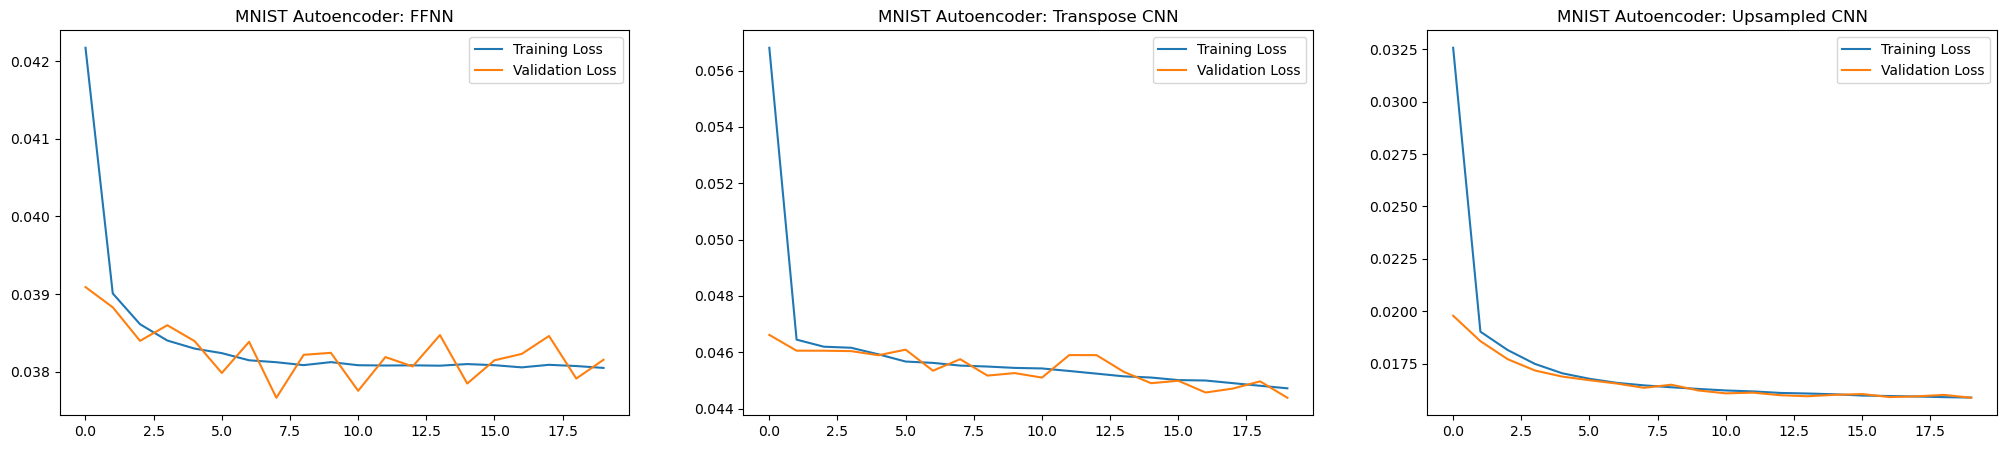

In [18]:
title=['FFNN','Transpose CNN','Upsampled CNN']
model_losses=[m1_loss,m2_loss,m3_loss]

fig=plt.figure(1,figsize=(25,5))
idx=1
for i in model_losses:
  ax=fig.add_subplot(1,3,idx)
  ax.plot(i['train'],label="Training Loss")
  ax.plot(i['valid'],label="Validation Loss")
  ax.set_title('MNIST Autoencoder: '+title[idx-1])
  idx+=1
  plt.legend();

## Testing Phase

In [19]:
def test(model,state='fully'):
    # obtain one batch of test images
    dataiter = iter(test_loader)
    images, _ =next(dataiter)
    if use_cuda and torch.cuda.is_available():
        images=images.cuda()
    if state=='fully':
        images = images.view(images.size(0), -1)

    noisy_images = add_noise(images)
    # get sample outputs
    output = model(noisy_images)
    # prep images for display
    images = images.cpu().numpy()
    noisy_images = noisy_images.cpu().numpy()
    # output is resized into a batch of images
    output = output.view(batch_size, 1, 28, 28).cpu().detach().numpy()
    # use detach when it's an output that requires_grad


    # plot the first ten input images and then reconstructed images
    fig, axes = plt.subplots(nrows=3, ncols=10, sharex=True, sharey=True, figsize=(25,6))

    # input images on top row, reconstructions on bottom
    for imgs, row in zip([noisy_images, output,images], axes):
        for img, ax in zip(imgs, row):
            if state=='fully':
                img = img.reshape(1, 28, 28)
            ax.imshow(np.squeeze(img), cmap='gray')
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)
            

## FFNN Autoencoder

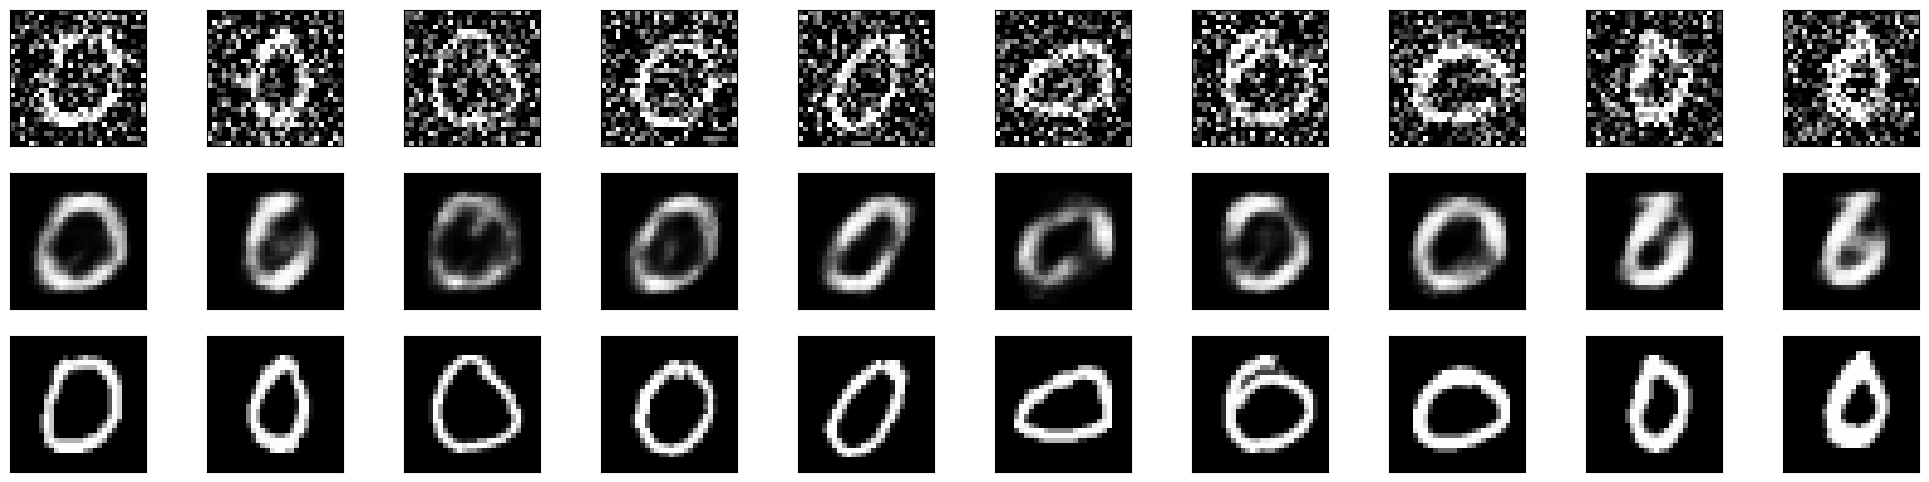

In [20]:
test(model_1)

## Transpose CNN Autoencoder

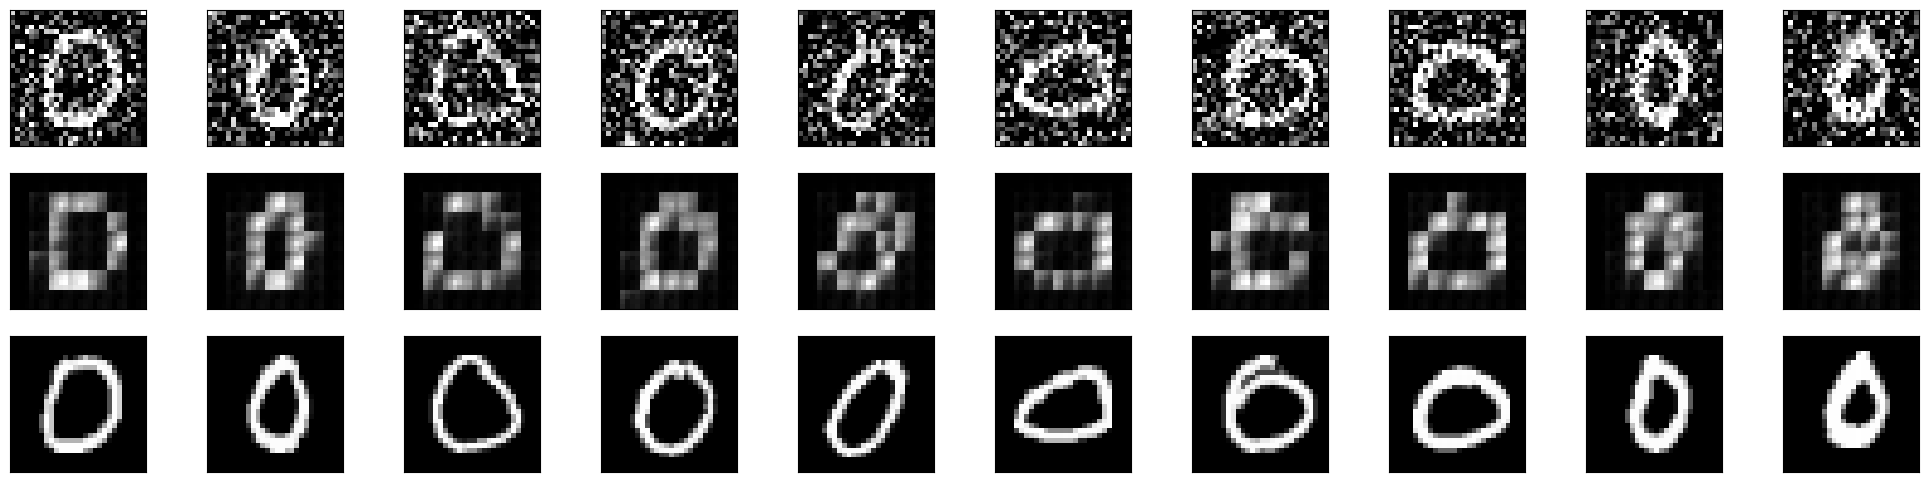

In [21]:
test(model_2,'conv')

## Upsampled CNN Autoencoder

C:\Users\Divyansh Sharma\AppData\Local\Temp\ipykernel_24560\219568314.py:42: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')
C:\Users\Divyansh Sharma\AppData\Local\Temp\ipykernel_24560\219568314.py:44: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')


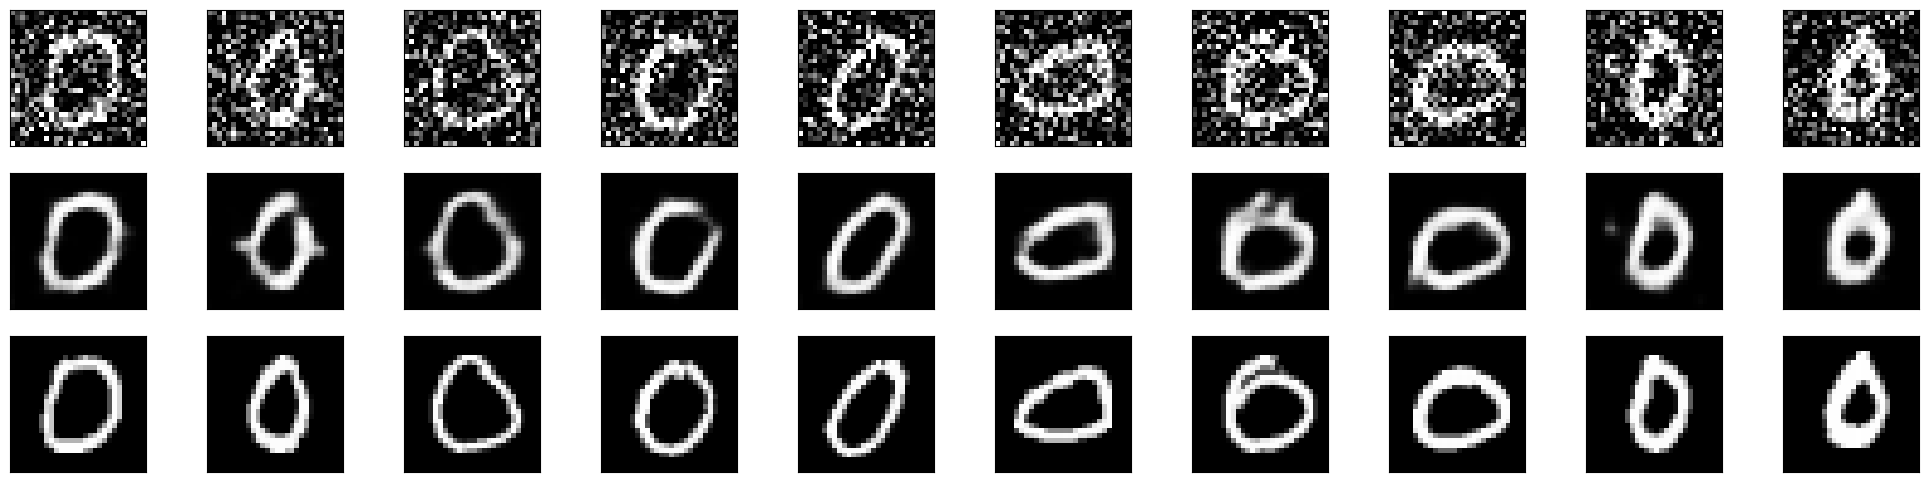

In [22]:
test(model_3,'conv')